In [1]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df


mapped_dataset = {}
with open("ssGSEA/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)
    
abnormal_counts = []
nan_counts = []
for k, v in genes_mapping.items():
    if isinstance(v[0], float) and math.isnan(v[0]):
        nan_counts.append([k, v])
        abnormal_counts.append([k,v])
    elif len(v) > 1 and isinstance(v[0], str):
        abnormal_counts.append([k,v])
        genes_mapping[k]=[v[0]]
            
def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]  # Remove version
    hugo = mapping.get(ensembl_id, [col])  # fallback: leave as is if not found
    return str(hugo[0])
    

for k in nan_counts:
    genes_mapping.pop(k[0], None)

genes_cols = []
for col in original_data.columns:
    if col.startswith("ENSG"):
        genes_cols.append(col)
        
symbols_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

In [2]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0):

    ph_column, ph_values = next(iter(phenotypes.items()))
    if len(ph_values) != 2:
        raise ValueError(f"Phenotype values list must contain exactly two values, got: {ph_values}")

    phenotype_A, phenotype_B = ph_values

    phenotypeA_samples = metadata[metadata[ph_column] == phenotype_A][id_col].values.tolist()
    phenotypeB_samples = metadata[metadata[ph_column] == phenotype_B][id_col].values.tolist()

    if len(phenotypeA_samples) == 0 or len(phenotypeB_samples) == 0:
        raise ValueError("One of the phenotype groups has no samples.")

    phenotypeA_DF = gene_expressions.loc[phenotypeA_samples, :]
    phenotypeB_DF = gene_expressions.loc[phenotypeB_samples, :]

    genelist = gene_expressions.columns.tolist()

    def process_gene(gene):
        phenotypeA_exp = phenotypeA_DF[gene].values
        phenotypeB_exp = phenotypeB_DF[gene].values

        # Edge case flags
        status = []

        # Case: contains both +inf and -inf in phenotypeA_exp or phenotypeB_exp
        def get_inf_flags(arr):
            arr = np.asarray(arr)
            return np.isposinf(arr).any(), np.isneginf(arr).any()

        posinf_A, neginf_A = get_inf_flags(phenotypeA_exp)
        posinf_B, neginf_B = get_inf_flags(phenotypeB_exp)

        if posinf_A and neginf_A:
            status.append("A_contains_posinf_and_neginf")
        if posinf_B and neginf_B:
            status.append("B_contains_posinf_and_neginf")

        # Handle arrays full of NaN or empty
        if np.all(np.isnan(phenotypeA_exp)) or len(phenotypeA_exp) == 0:
            status.append(f"A_all_nan_or_empty")
        if np.all(np.isnan(phenotypeB_exp)) or len(phenotypeB_exp) == 0:
            status.append(f"B_all_nan_or_empty")

        # Remove NaNs (rank-sum test can't handle)
        cleaned_A_exp = phenotypeA_exp[~np.isnan(phenotypeA_exp)]
        cleaned_B_exp = phenotypeB_exp[~np.isnan(phenotypeB_exp)]

        if len(cleaned_A_exp) == 0 or len(cleaned_B_exp) == 0:
            pvalue = np.nan
            status.append("No_data")
        else:
            # Check if both are constant or identical
            if np.all(cleaned_A_exp == cleaned_A_exp[0]) and np.all(cleaned_B_exp == cleaned_B_exp[0]) and cleaned_A_exp[0] == cleaned_B_exp[0]:
                pvalue = 1.0
                status.append("Identical")
            else:
                try:
                    _, pvalue = ranksums(cleaned_A_exp, cleaned_B_exp, alternative='two-sided')
                    if np.isnan(pvalue):
                        status.append("p_nan")
                except Exception as e:
                    pvalue = np.nan
                    status.append(f"ranksums_error:{str(e)}")

        mean_A = np.nanmean(cleaned_A_exp) if len(cleaned_A_exp) else np.nan
        mean_B = np.nanmean(cleaned_B_exp) if len(cleaned_B_exp) else np.nan

        # Log2FC with safe handling (including zeros, NaN, infinite)
        # Case: mean_A or mean_B < 0
        if np.isnan(mean_A) or np.isnan(mean_B):
            log2fc = np.nan
            status.append("FC_nan")
        elif mean_A < 0 or mean_B < 0:
            log2fc = np.nan
            status.append("Mean_negative")
        elif mean_A == mean_B == 0:
            log2fc = 0.0
            status.append("FC_both_zero")
        elif mean_B == 0:
            log2fc = np.inf if mean_A > 0 else np.nan
            status.append("FC_div_zero")
        elif mean_A == 0:
            log2fc = -np.inf if mean_B > 0 else np.nan
            status.append("FC_div_zero")
        else:
            log2fc = np.log2(mean_A / mean_B)

        if not status:
            status = ["ok"]
        return pvalue, log2fc, ";".join(status)

    # Parallel processing
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(process_gene)(gene) for gene in genelist
    )
    pvalues, log2FCs, statusflags = zip(*results)

    results_df = pd.DataFrame(
        {
            "Gene": genelist,
            "P_value": pvalues,
            "Log2FC": log2FCs,
            "Status": statusflags,
        }
    )
    
    # Multiple testing correction (protect against all-NaN p-values)
    pvalues = np.asarray(results_df["P_value"].values)
    valid_p_mask = ~pd.isnull(pvalues)
    valid_pvalues = np.array(pvalues)[valid_p_mask]
    qvalues = np.full_like(pvalues, np.nan, dtype=np.double)
    if valid_pvalues.size > 0:
        _, qvals_valid, _, _ = multipletests(valid_pvalues, method='fdr_bh')
        qvalues = np.array(qvalues)
        qvalues[valid_p_mask] = qvals_valid
    
    results_df['Q_value'] = qvalues
    # Rank_Score is only computed for valid Log2FC and Q_value
    results_df["Rank_Score"] = np.where(
        pd.isnull(results_df["Log2FC"]) | pd.isnull(results_df["Q_value"]),
        np.nan,
        (results_df["Log2FC"]) * (-np.log10(results_df["Q_value"]))
    )
    return results_df

In [3]:
degs_results = {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    # genelist = data.columns.tolist()[54:-1]
    gene_expressions_t = symbols_dataset_dict[name].T
    gene_expressions_t = pd.DataFrame(gene_expressions_t.values[1:], columns=gene_expressions_t.values[0], index =gene_expressions_t.index[1:])
    gene_expressions_t = gene_expressions_t.apply(pd.to_numeric, errors="coerce")
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "Deletion_9p21.3": data['Deletion_9p21.3'].values.tolist()}
    )
    # gene_expressions = data[genelist]
    id_col = "Patient"
    phenotypes = {"Deletion_9p21.3": ["MUT","WT"]}
    degs_df = degs_analysis(gene_expressions_t, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    degs_results[name] = degs_df

----DEGs Analysis Origin ----
----DEGs Analysis avatarsk5_42 ----
----DEGs Analysis avatarsk10_42 ----
----DEGs Analysis ctgan_42 ----
----DEGs Analysis gaussiancopula_42 ----


/tmp/ipykernel_362645/3285701419.py:95: RuntimeWarning: divide by zero encountered in log2
/tmp/ipykernel_362645/3285701419.py:95: RuntimeWarning: divide by zero encountered in log2


----DEGs Analysis synthpop_42 ----
----DEGs Analysis tvae_42 ----


ValueError: One of the phenotype groups has no samples.

In [47]:
def get_safe_df(df, log2fc_col='Log2FC', status_col='Status'):
    # coerce to numeric (non-numeric -> NaN)
    log2fc_numeric = pd.to_numeric(df[log2fc_col], errors='coerce')

    # Option A: keep only finite values
    mask_finite = np.isfinite(log2fc_numeric.values)

    safe_df = df.loc[mask_finite].copy()

    # keep only ok status
    safe_df = safe_df[safe_df[status_col] == 'ok'].copy()
    return safe_df

# safe_df = get_safe_df(degs_results['gaussiancopula_42'])

In [63]:
import gseapy as gp
hallmarks_gmt = "h.all.v2025.1.Hs.symbols.gmt"
GSEA_overall_3 = {}
for name, degs in degs_results.items():
    print(f"----GSEA {name}----")
    safe_df = get_safe_df(degs)
    safe_df['Rank_Score_2'] = safe_df['Log2FC']*(-np.log10(safe_df['Q_value']))
    safe_df['Rank_Score_3'] = np.sign(safe_df['Log2FC'])*(-np.log10(safe_df['Q_value']))
    print("Remove genes", degs.shape[0] - safe_df.shape[0])
    ranked_results_df = safe_df.sort_values(by="Rank_Score_3", ascending = False)
    rnk = ranked_results_df[["Gene","Rank_Score_3"]].set_index("Gene")
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=hallmarks_gmt,
                         threads=32,
                         permutation_num=10000, # reduce number to speed up testing
                         outdir=None, # don't write to disk
                         seed=seed,
                         verbose=True)
    prerank_overall = pre_res.res2d
    # prerank_overall.to_csv(f"GSEA/GSEA_{name}_{seed}.csv",index = False)
    GSEA_overall_3[name] = prerank_overall

2025-12-08 17:37:37,526 [WARNING] Duplicated values found in preranked stats: 85.11% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-08 17:37:37,527 [INFO] Parsing data files for GSEA.............................
2025-12-08 17:37:37,574 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-08 17:37:37,576 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-08 17:37:37,577 [INFO] Start to run GSEA...Might take a while..................


----GSEA Origin----
Remove genes 0


2025-12-08 17:37:56,004 [INFO] Congratulations. GSEApy runs successfully................

2025-12-08 17:37:56,049 [WARNING] Duplicated values found in preranked stats: 90.16% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-08 17:37:56,051 [INFO] Parsing data files for GSEA.............................
2025-12-08 17:37:56,097 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-08 17:37:56,098 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-08 17:37:56,099 [INFO] Start to run GSEA...Might take a while..................


----GSEA avatarsk5_42----
Remove genes 0


2025-12-08 17:38:14,595 [INFO] Congratulations. GSEApy runs successfully................

2025-12-08 17:38:14,649 [WARNING] Duplicated values found in preranked stats: 92.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-08 17:38:14,650 [INFO] Parsing data files for GSEA.............................
2025-12-08 17:38:14,697 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-08 17:38:14,699 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-08 17:38:14,700 [INFO] Start to run GSEA...Might take a while..................


...

2025-12-08 17:38:52,107 [INFO] Congratulations. GSEApy runs successfully................

2025-12-08 17:38:52,154 [WARNING] Duplicated values found in preranked stats: 90.21% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-08 17:38:52,155 [INFO] Parsing data files for GSEA.............................
2025-12-08 17:38:52,200 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-08 17:38:52,202 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-08 17:38:52,203 [INFO] Start to run GSEA...Might take a while..................


----GSEA gaussiancopula_42----
Remove genes 151


2025-12-08 17:39:10,694 [INFO] Congratulations. GSEApy runs successfully................

2025-12-08 17:39:10,741 [WARNING] Duplicated values found in preranked stats: 98.06% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-12-08 17:39:10,742 [INFO] Parsing data files for GSEA.............................
2025-12-08 17:39:10,788 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-12-08 17:39:10,790 [INFO] 0050 gene_sets used for further statistical testing.....
2025-12-08 17:39:10,791 [INFO] Start to run GSEA...Might take a while..................


----GSEA synthpop_42----
Remove genes 0


2025-12-08 17:39:29,409 [INFO] Congratulations. GSEApy runs successfully................



In [77]:
GSEA_overall['Origin'].sort_values(by='FDR q-val').head() 

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_OXIDATIVE_PHOSPHORYLATION,-0.768619,-1.885508,0.0,0.0,0.0,51/184,11.32%,ACAT1;PMPCA;ACAA2;ALDH6A1;ETFDH;NDUFA8;SURF1;S...
1,prerank,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,0.803101,1.754643,0.0,0.0,0.0,69/197,7.96%,ADAM12;TGFBI;COL11A1;LRRC15;MATN3;WNT5A;THBS2;...
2,prerank,HALLMARK_COAGULATION,0.803001,1.69868,0.0,0.001253,0.0023,47/136,8.32%,F2;MMP10;C1R;TMPRSS6;C1S;TF;MMP9;F3;SERPINE1;F...
4,prerank,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,0.808775,1.666819,0.000298,0.002652,0.0073,16/108,6.28%,IGFBP1;PSAT1;SLC7A5;KDELR3;CEBPB;ASNS;HSP90B1;...
3,prerank,HALLMARK_FATTY_ACID_METABOLISM,-0.695627,-1.683537,0.0,0.002737,0.0069,32/156,5.95%,ACADL;AQP7;HSDL2;AUH;CRAT;GRHPR;CYP4A11;ACAA2;...


In [78]:
from collections import Iterable
from typing import Dict, Optional, Tuple, Any, List

def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "P_value",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

/tmp/ipykernel_1937231/2407618329.py:1: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  from collections import Iterable


In [82]:
orig_paths = extract_significant_pathways(GSEA_overall_3["Origin"], term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
synth_paths_dict = {k: extract_significant_pathways(v, term_col="Term", adj_p_col="FDR q-val", threshold=0.05)
                     for k, v in GSEA_overall_3.items() if k != "Origin"}
jaccard_df = compute_jaccard_indices(orig_paths, synth_paths_dict)
# jaccard_df.to_csv(f"GSEA/JaccardIndex_{seed}_9p213Del.csv", index = False)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_42,21,30,13,38,0.342105
1,avatarsk10_42,21,28,14,35,0.400000
2,ctgan_42,21,0,0,21,0.000000
3,gaussiancopula_42,21,17,14,24,0.583333
4,synthpop_42,21,20,10,31,0.322581


In [84]:
from scipy.stats import spearmanr
GSEA_list = []
for name, df in GSEA_overall_3.items():
    df["Dataset"] = name
    GSEA_list.append(df)
GSEA_df = pd.concat(GSEA_list, axis = 0)
pivot_df = GSEA_df.pivot_table(
    index="Term",
    columns="Dataset",
    values="NES"
)


origin_values = pivot_df["Origin"]

results = []

for dataset in pivot_df.columns:
    if dataset == "Origin":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
# spearman_df.to_csv(f"GSEA/Spearman_df{seed}.csv", index = False)
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.419544,2.422365e-03,50
1,avatarsk5_42,0.365186,9.115639e-03,50
2,ctgan_42,-0.221609,1.219411e-01,50
3,gaussiancopula_42,0.736375,1.096577e-09,50
4,synthpop_42,0.386795,5.523953e-03,50


In [128]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

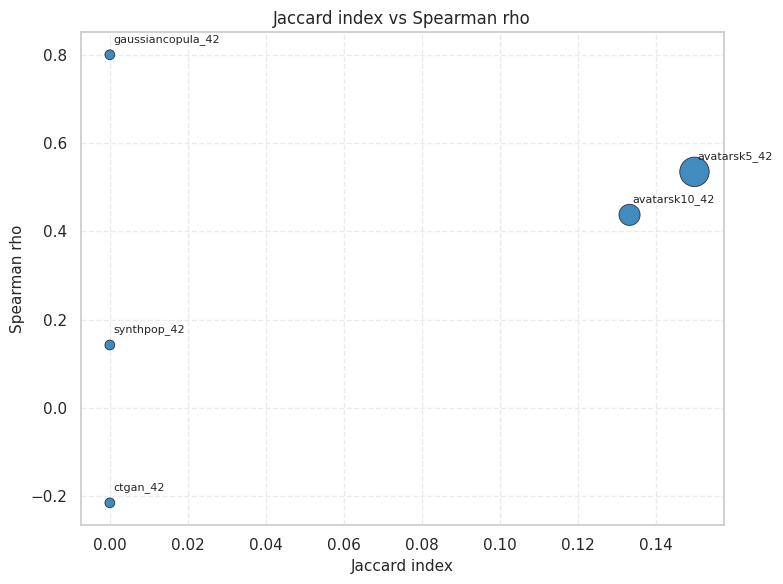

In [130]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=f'GSEA/JaccardSpearman9p21_3_{seed}.png')
plt.show()

In [131]:
from typing import List, Optional, Any, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches

def plot_pathway_df(
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    color_col: Optional[str] = None,   # ignored when using p-value bins
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    p_threshold: float = 0.05,         # kept but not used for color now
    fig_width_min: float = 10.0,
    marker_size: float = 100.0,        # fixed marker size (no scaling)
    show: bool = True,
    title: str = "Pathway bubble plot",
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    eps: float = 1e-9,                 # small epsilon added to p-values when needed
    xlim: Tuple[float, float] = (-3.0, 3.0),  # fixed x-axis range
    pval_bin_colors: List[str] = None,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:

    """
    Plot a bubble plot for pathways with:
    - fixed x-axis range (default -3 to 3, configurable via `xlim`)
    - discrete bubble colors based on p-value bins:
        p < 0.01          -> first color
        0.01 ≤ p < 0.05   -> second color
        0.05 ≤ p < 0.25   -> third color
        p ≥ 0.25          -> fourth color
    """

    if df is None or df.empty:
        raise ValueError("Input DataFrame `df` is empty or None.")
    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")
    if p_value_col not in df.columns:
        raise ValueError(f"p_value_col '{p_value_col}' not found in DataFrame columns.")

    # default colors if not provided
    if pval_bin_colors is None:
        # p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25
        pval_bin_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]

    df = df.copy()

    # Coerce numeric columns safely
    df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.",
                ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    # --- Assign p-value bins and colors ---
    bins = [0, 0.01, 0.05, 0.25, 1.0 + eps]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    df_plot["pvalue_bin"] = pd.cut(
        df_plot[p_value_col],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )
    color_map = dict(zip(bin_labels, pval_bin_colors))

    # IMPORTANT FIX: convert to object/str before fillna("#cccccc")
    bubble_colors = df_plot["pvalue_bin"].map(color_map).astype(object)
    bubble_colors = bubble_colors.fillna("#cccccc")

    # --- Determine ordering of y labels ---
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    # Final y labels (reverse for top-to-bottom plotting)
    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # Extract plotting arrays
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values

    # Fixed marker size
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # --- Create figure ---
    FIG_WIDTH = max(fig_width_min, 10.0)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 2, 6)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=bubble_colors,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # Fixed x-axis range
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlim(xlim[0], xlim[1])

    # y-ticks and labels
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Highlight pathways on y-axis labels
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # --- Discrete legend for p-value bins instead of colorbar ---
    legend_patches = [
        mpatches.Patch(color=color_map[l], label=l)
        for l in bin_labels
    ]
    ax.legend(
        handles=legend_patches,
        title="p-value",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )

    # Layout
    plt.subplots_adjust(left=0.30, right=0.80, top=0.95, bottom=0.08)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    # attach mapping y positions to df_plot for downstream usage
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    return (fig, df_plot) if return_dataframe else (fig, None)

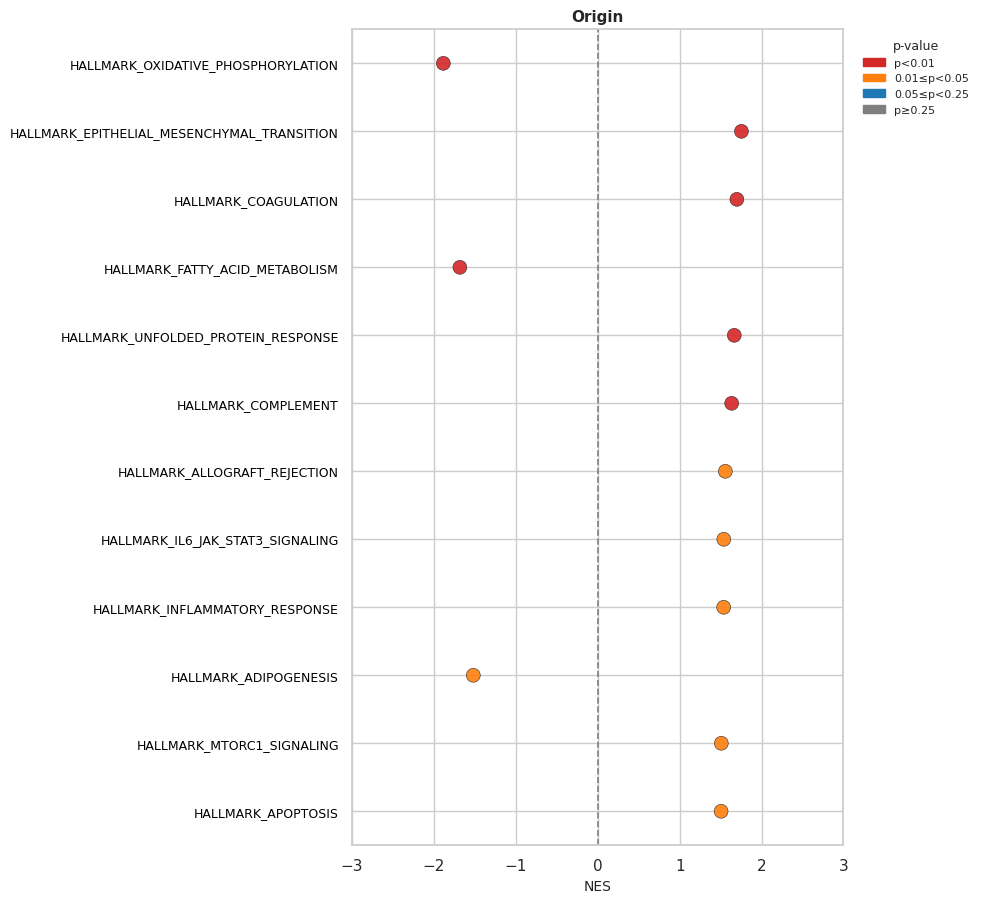

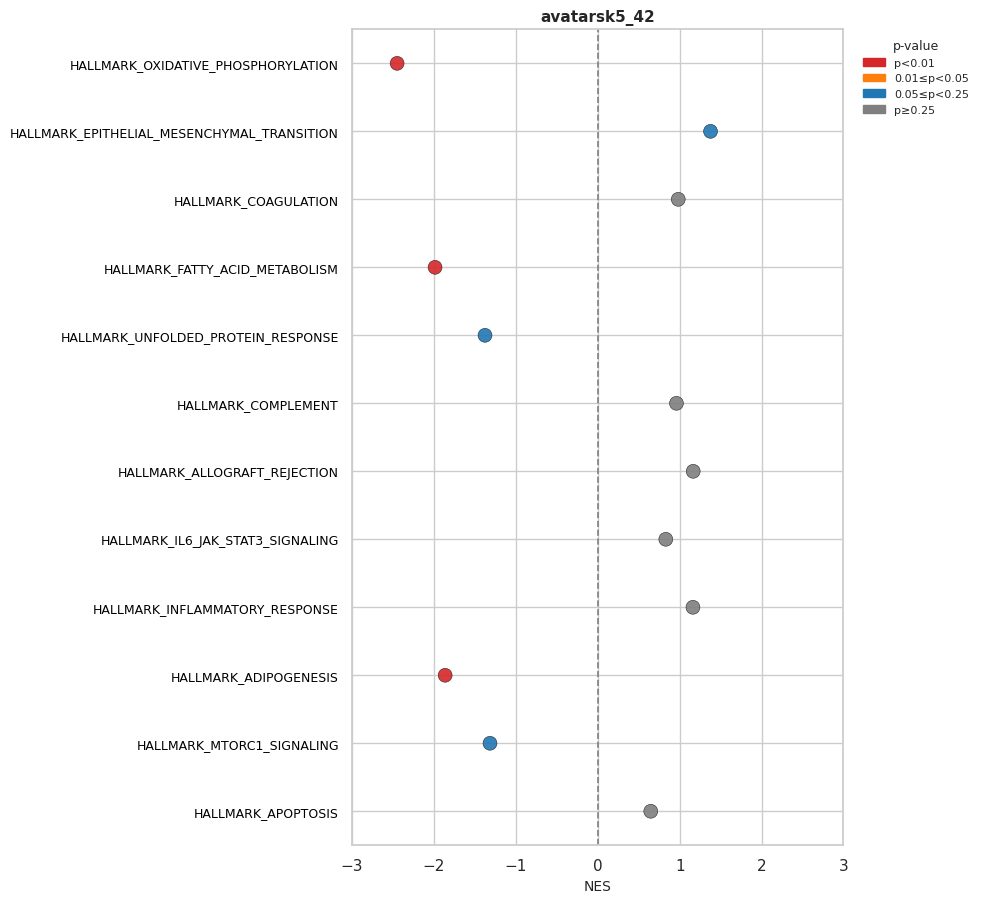

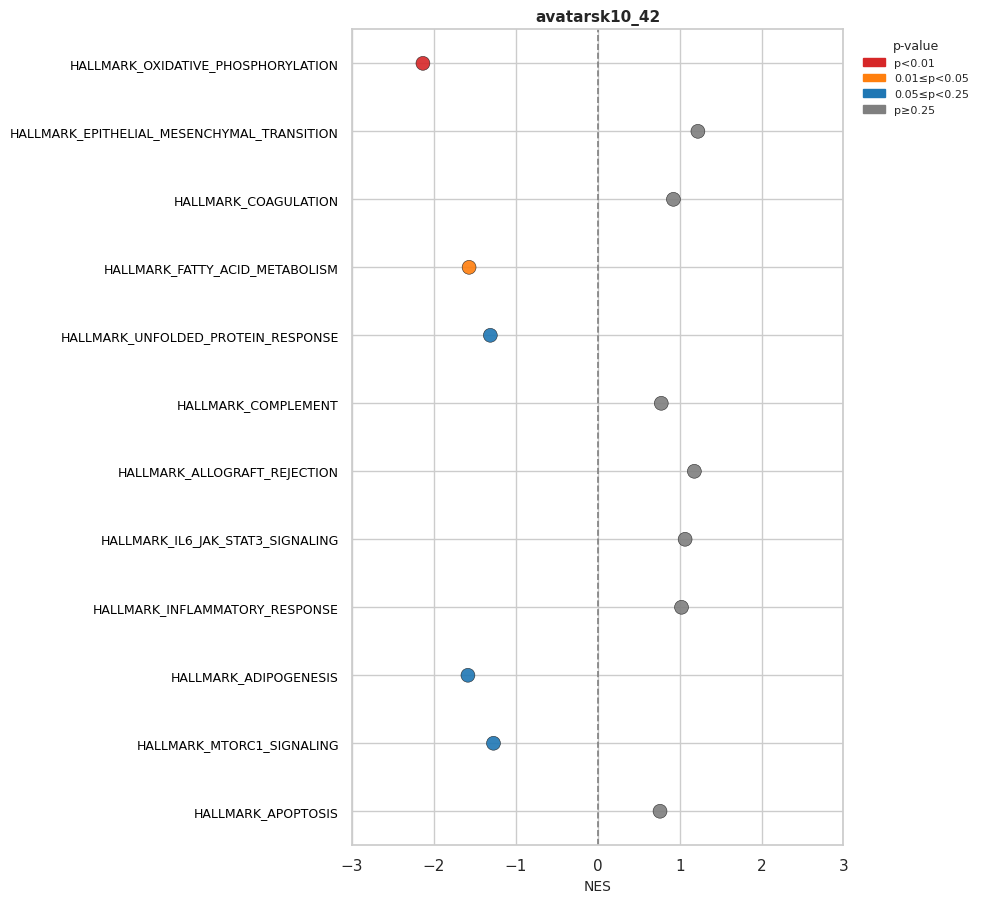

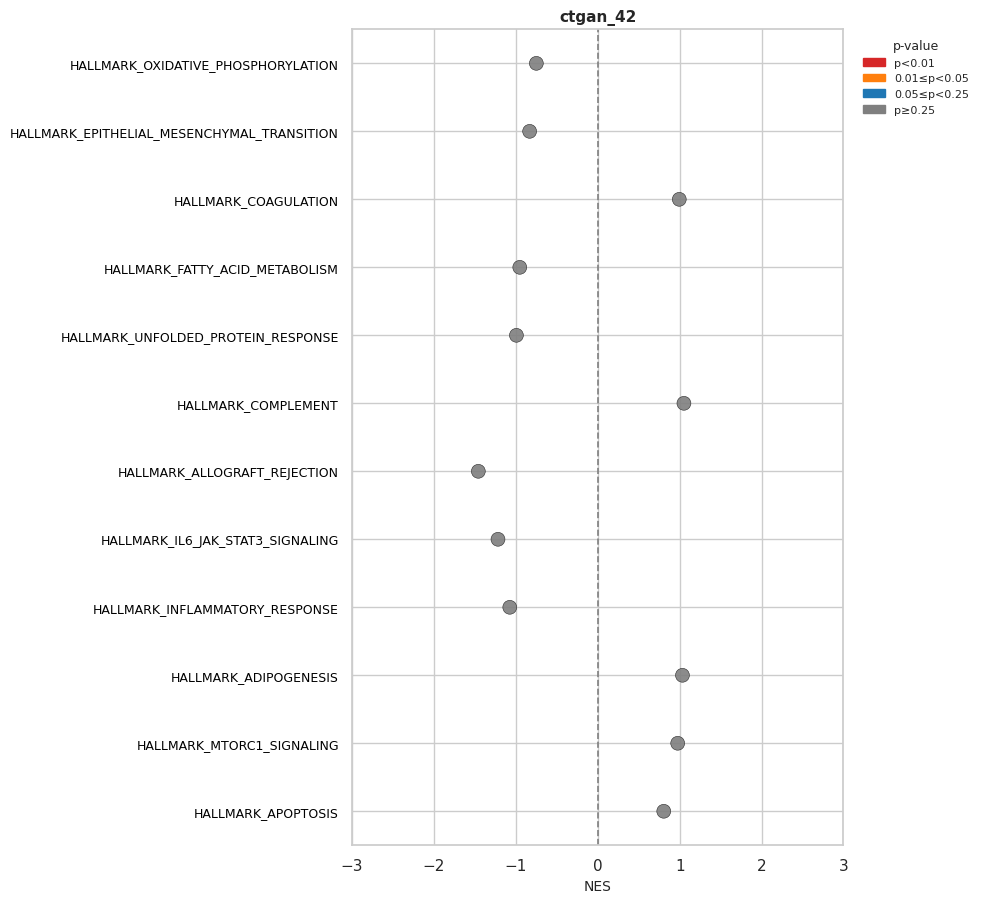

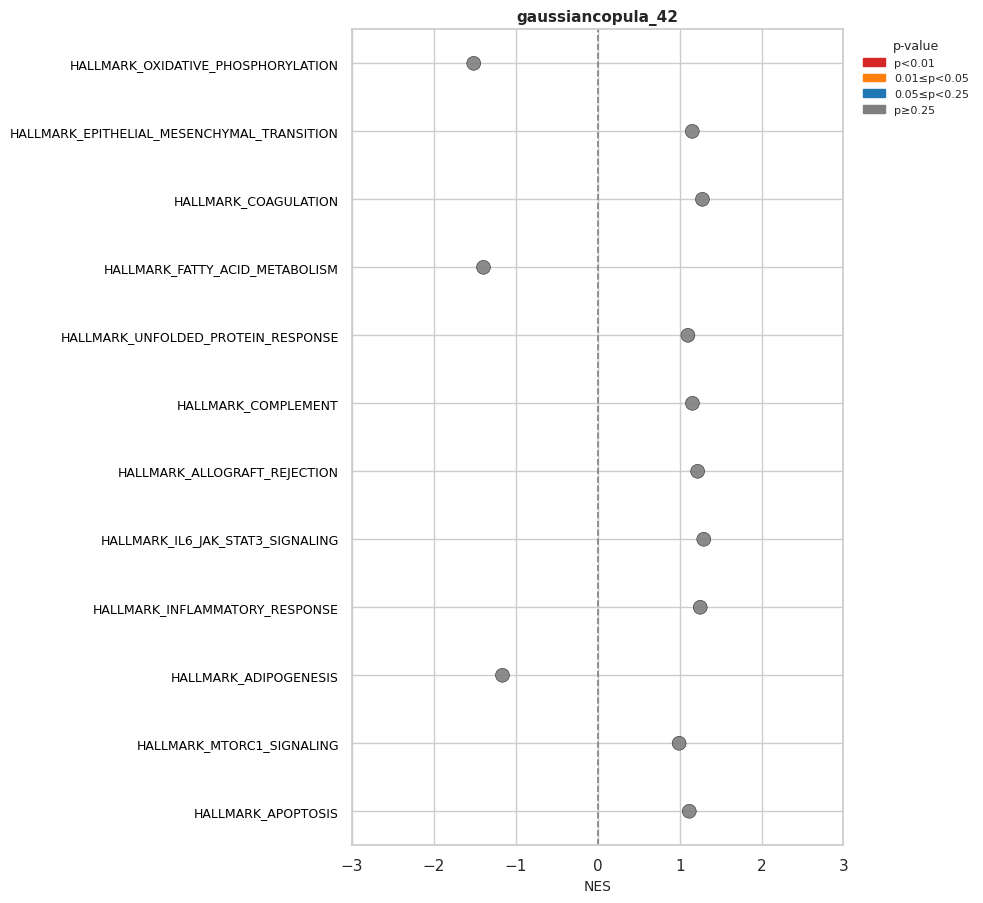

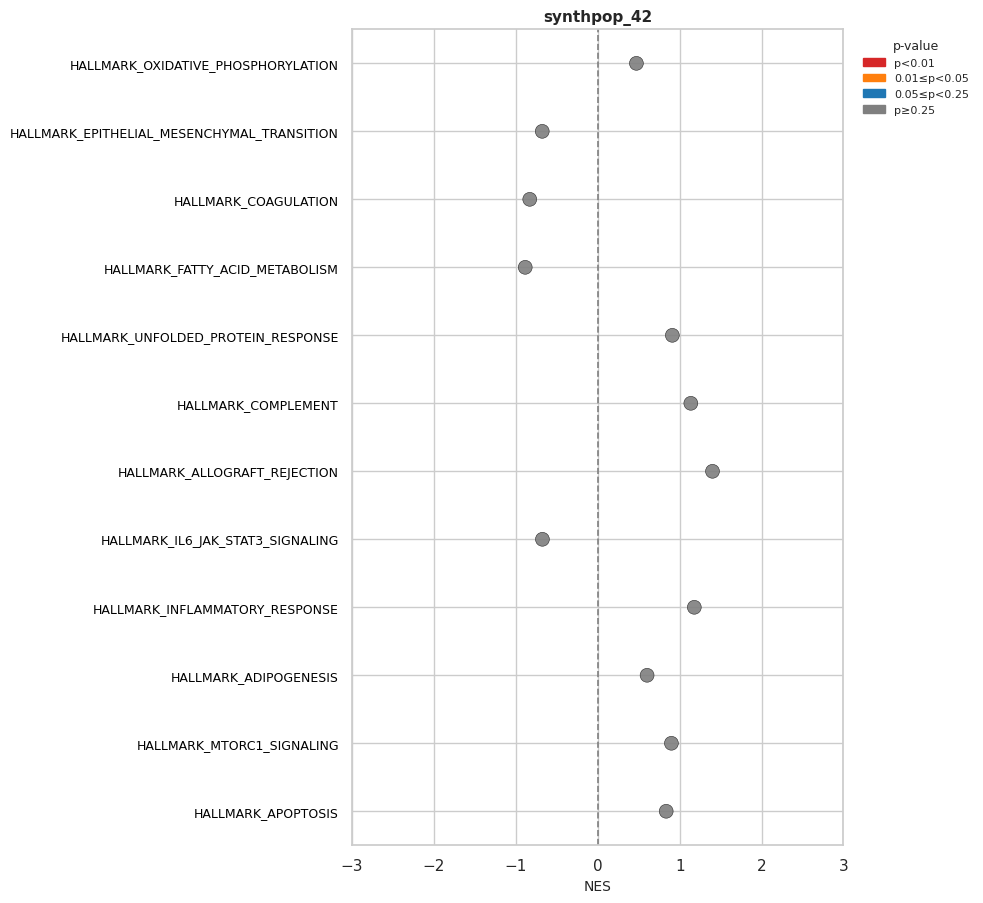

In [132]:
# Example usage:
highligt_paths = ['HALLMARK_HYPOXIA','HALLMARK_ANGIOGENESIS','HALLMARK_GLYCOLYSIS']
for tool, GSEA_df in GSEA_overall.items():
    fig, df_out = plot_pathway_df(GSEA_df, ref_pathway_list=orig_paths, xlim=(-3, 3), x_col="NES", y_col="Term",
                                  p_value_col="FDR q-val", highlight_pathways=highligt_paths, title = f"{tool}",
                                    # save_path =f"GSEA/BubblePlot_{tool}_{seed}.png",
                                   color_col=None, order_by=None)

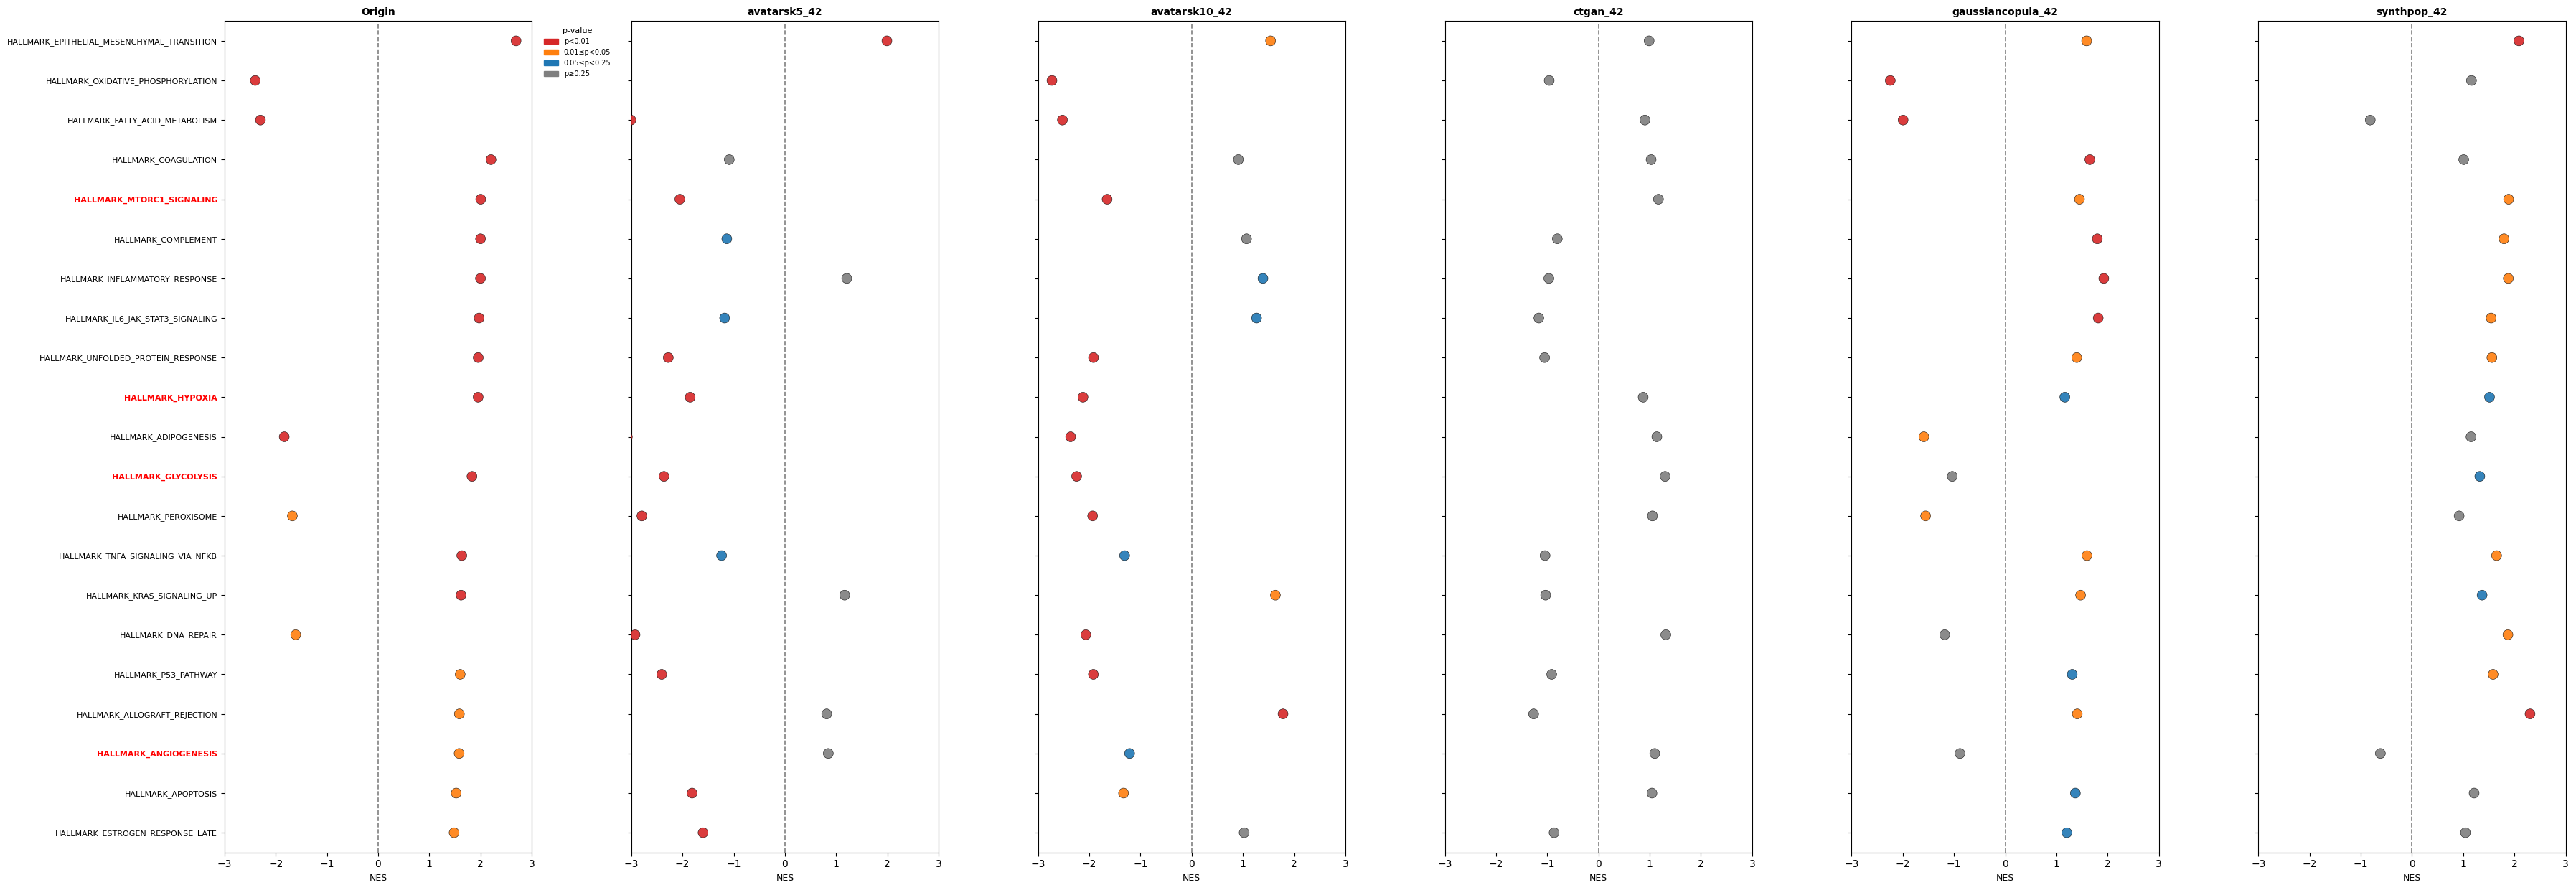

In [86]:
# Example usage for grid
from typing import List, Optional, Any, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_pathway_df_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    fig_xlim: Tuple[float, float] = (-3.0, 3.0),
    marker_size: float = 100.0,
    eps: float = 1e-9,
    pval_bin_colors: List[str] = None,
    title: str = "",
    add_legend: bool = False,
) -> pd.DataFrame:
    """
    Draw a pathway bubble plot for a single dataset into a given Axes.

    Colors are discrete p-value bins:
        p < 0.01          -> first color
        0.01 ≤ p < 0.05   -> second color
        0.05 ≤ p < 0.25   -> third color
        p ≥ 0.25          -> fourth color
    """

    if df is None or df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")
    if p_value_col not in df.columns:
        raise ValueError(f"p_value_col '{p_value_col}' not found in DataFrame columns.")

    # default colors if not provided
    if pval_bin_colors is None:
        # p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25
        pval_bin_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]

    df = df.copy()
    df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    # p-value bins
    bins = [0, 0.01, 0.05, 0.25, 1.0 + eps]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    df_plot["pvalue_bin"] = pd.cut(
        df_plot[p_value_col],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )
    color_map: Dict[str, str] = dict(zip(bin_labels, pval_bin_colors))

    # convert to object/str before fillna("#cccccc")
    bubble_colors = df_plot["pvalue_bin"].map(color_map).astype(object)
    bubble_colors = bubble_colors.fillna("#cccccc")

    # --- ordering of y labels ---
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # data for scatter
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # draw
    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=bubble_colors,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # fixed x-range
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlim(fig_xlim[0], fig_xlim[1])

    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

    # highlight y-ticks
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # legend (only once, on a chosen axis)
    if add_legend:
        legend_patches = [
            mpatches.Patch(color=color_map[l], label=l)
            for l in bin_labels
        ]
        ax.legend(
            handles=legend_patches,
            title="p-value",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=7,
            title_fontsize=8,
            frameon=False,
        )

    # return plot data with mapped y
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))
    return df_plot
highligt_paths = ['HALLMARK_MTORC1_SIGNALING','HALLMARK_HYPOXIA','HALLMARK_ANGIOGENESIS','HALLMARK_GLYCOLYSIS']

tools = list(GSEA_overall.keys())
n_tools = len(tools)

# choose grid layout, e.g. 2 columns
n_cols = 6
n_rows = int(np.ceil(n_tools / n_cols))

fig_width = 6 * n_cols
fig_height = max(0.5 * len(orig_paths) + 2, 6) * n_rows  # scale by number of pathways if you like

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True,
)

# normalize axes to 2D array
if n_rows == 1 and n_cols == 1:
    axes_grid = np.array([[axes]])
elif n_rows == 1 or n_cols == 1:
    axes_grid = np.array(axes).reshape(n_rows, n_cols)
else:
    axes_grid = axes

all_df_out = {}

for idx, tool in enumerate(tools):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes_grid[r, c]

    GSEA_df = GSEA_overall_3[tool]

    df_out = plot_pathway_df_ax(
        ax=ax,
        df=GSEA_df,
        ref_pathway_list=orig_paths,
        x_col="NES",
        y_col="Term",
        p_value_col="FDR q-val",
        highlight_pathways=highligt_paths,
        title=tool,
        fig_xlim=(-3, 3),
        marker_size=100.0,
        add_legend=(idx == 0),  # only first subplot shows legend
    )
    all_df_out[tool] = df_out

# Turn off empty axes if grid has more cells than tools
for j in range(n_tools, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes_grid[r, c].axis("off")

plt.tight_layout()
# plt.savefig("GSEA/9p21_3.png", dpi = 300)
plt.show()

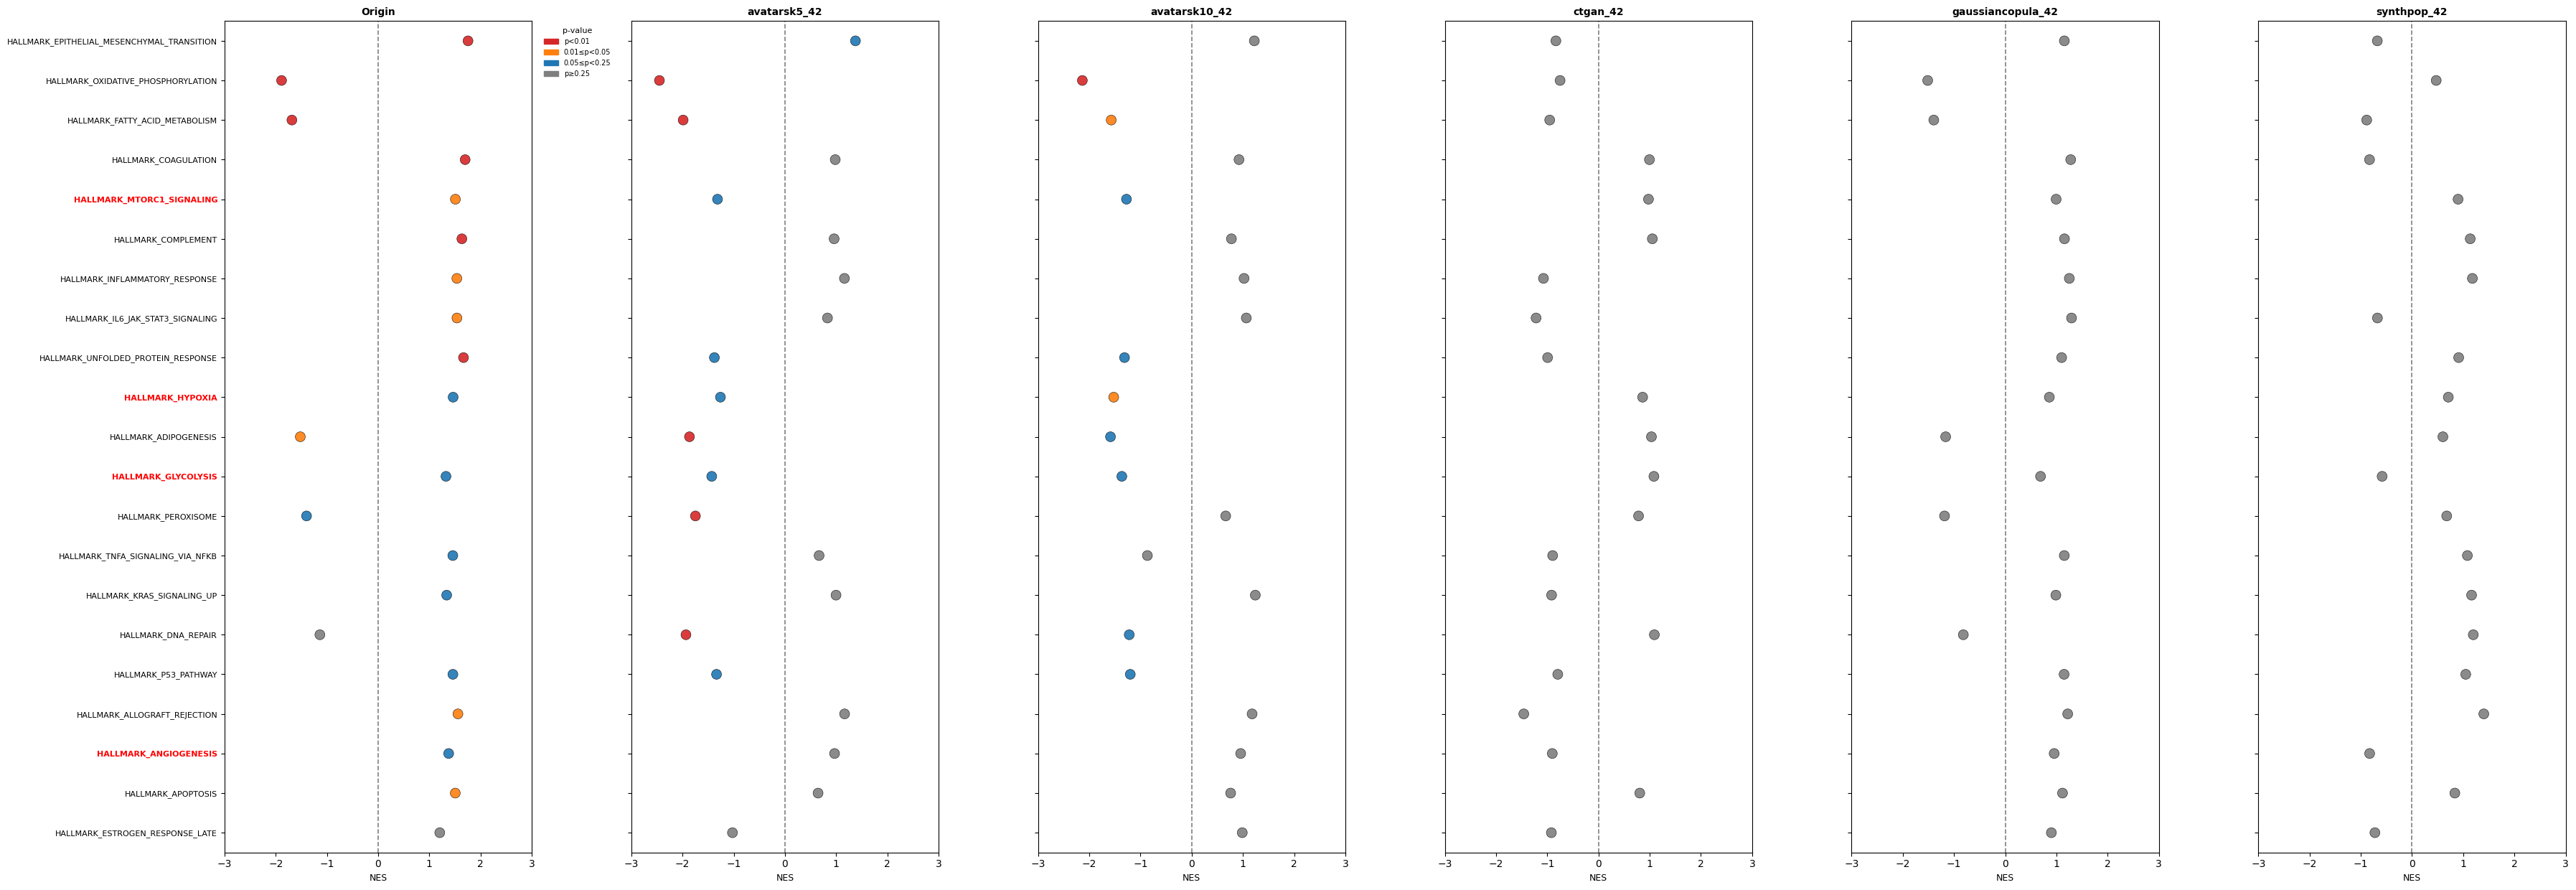

In [87]:
# Example usage for grid
from typing import List, Optional, Any, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_pathway_df_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    fig_xlim: Tuple[float, float] = (-3.0, 3.0),
    marker_size: float = 100.0,
    eps: float = 1e-9,
    pval_bin_colors: List[str] = None,
    title: str = "",
    add_legend: bool = False,
) -> pd.DataFrame:
    """
    Draw a pathway bubble plot for a single dataset into a given Axes.

    Colors are discrete p-value bins:
        p < 0.01          -> first color
        0.01 ≤ p < 0.05   -> second color
        0.05 ≤ p < 0.25   -> third color
        p ≥ 0.25          -> fourth color
    """

    if df is None or df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")
    if p_value_col not in df.columns:
        raise ValueError(f"p_value_col '{p_value_col}' not found in DataFrame columns.")

    # default colors if not provided
    if pval_bin_colors is None:
        # p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25
        pval_bin_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]

    df = df.copy()
    df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    # p-value bins
    bins = [0, 0.01, 0.05, 0.25, 1.0 + eps]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    df_plot["pvalue_bin"] = pd.cut(
        df_plot[p_value_col],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )
    color_map: Dict[str, str] = dict(zip(bin_labels, pval_bin_colors))

    # convert to object/str before fillna("#cccccc")
    bubble_colors = df_plot["pvalue_bin"].map(color_map).astype(object)
    bubble_colors = bubble_colors.fillna("#cccccc")

    # --- ordering of y labels ---
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # data for scatter
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # draw
    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=bubble_colors,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # fixed x-range
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlim(fig_xlim[0], fig_xlim[1])

    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

    # highlight y-ticks
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # legend (only once, on a chosen axis)
    if add_legend:
        legend_patches = [
            mpatches.Patch(color=color_map[l], label=l)
            for l in bin_labels
        ]
        ax.legend(
            handles=legend_patches,
            title="p-value",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=7,
            title_fontsize=8,
            frameon=False,
        )

    # return plot data with mapped y
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))
    return df_plot
highligt_paths = ['HALLMARK_MTORC1_SIGNALING','HALLMARK_HYPOXIA','HALLMARK_ANGIOGENESIS','HALLMARK_GLYCOLYSIS']

tools = list(GSEA_overall.keys())
n_tools = len(tools)

# choose grid layout, e.g. 2 columns
n_cols = 6
n_rows = int(np.ceil(n_tools / n_cols))

fig_width = 6 * n_cols
fig_height = max(0.5 * len(orig_paths) + 2, 6) * n_rows  # scale by number of pathways if you like

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True,
)

# normalize axes to 2D array
if n_rows == 1 and n_cols == 1:
    axes_grid = np.array([[axes]])
elif n_rows == 1 or n_cols == 1:
    axes_grid = np.array(axes).reshape(n_rows, n_cols)
else:
    axes_grid = axes

all_df_out = {}

for idx, tool in enumerate(tools):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes_grid[r, c]

    GSEA_df = GSEA_overall[tool]

    df_out = plot_pathway_df_ax(
        ax=ax,
        df=GSEA_df,
        ref_pathway_list=orig_paths,
        x_col="NES",
        y_col="Term",
        p_value_col="FDR q-val",
        highlight_pathways=highligt_paths,
        title=tool,
        fig_xlim=(-3, 3),
        marker_size=100.0,
        add_legend=(idx == 0),  # only first subplot shows legend
    )
    all_df_out[tool] = df_out

# Turn off empty axes if grid has more cells than tools
for j in range(n_tools, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes_grid[r, c].axis("off")

plt.tight_layout()
# plt.savefig("GSEA/9p21_3.png", dpi = 300)
plt.show()